In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Make plots look nice
sns.set_theme(style="whitegrid")

In [32]:
csv_folder = Path("../nepse-data/data/company-wise")

# Checking folder exists or not
if not csv_folder.exists():
    raise FileNotFoundError(f"Folder not found: {csv_folder}")

# List all CSV
all_csvs = list(csv_folder.glob("*.csv"))
print(f"Found {len(all_csvs)} CSV files")
print([f.name for f in all_csvs[:10]])



Found 124 CSV files
['UNHPL.csv', 'PFL.csv', 'MDB.csv', 'JBBL.csv', 'SCB.csv', 'SSHL.csv', 'ALICL.csv', 'MHNL.csv', 'SHINE.csv', 'KRBL.csv']


In [33]:
# Load all CSVs into a single DataFrame
df_list = []
for file in all_csvs:
    temp = pd.read_csv(file)
    temp['Company'] = file.stem  # add company name column
    df_list.append(temp)

combined_df = pd.concat(df_list, ignore_index=True)
print("Combined DataFrame shape:", combined_df.shape)


Combined DataFrame shape: (261155, 10)


In [34]:
combined_df.head()


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,Company
0,2019-07-24,95.0,95.0,94.0,94.0,-5.05,100.0,9450.0,-1,UNHPL
1,2019-07-25,90.0,90.0,85.0,85.0,-9.57,3500.0,298087.0,-1,UNHPL
2,2019-07-28,84.0,84.0,77.0,78.0,-8.24,821.0,63698.0,-1,UNHPL
3,2019-07-29,77.0,78.0,72.0,78.0,0.00,1900.0,142260.0,0,UNHPL
4,2019-07-30,77.0,77.0,73.0,73.0,-6.41,3410.0,252320.0,-1,UNHPL


In [35]:
combined_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261155 entries, 0 to 261154
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   published_date   261155 non-null  object 
 1   open             261155 non-null  float64
 2   high             261155 non-null  float64
 3   low              261155 non-null  float64
 4   close            261155 non-null  float64
 5   per_change       261068 non-null  float64
 6   traded_quantity  261155 non-null  float64
 7   traded_amount    261155 non-null  float64
 8   status           261155 non-null  int64  
 9   Company          261155 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 19.9+ MB


In [36]:
# Convert date to datetime
combined_df['published_date'] = pd.to_datetime(combined_df['published_date'], errors='coerce')

# Fill missing per_change with 0
combined_df['per_change'] = combined_df['per_change'].fillna(0)

# Drop duplicate rows
combined_df = combined_df.drop_duplicates()

# Quick stats check
combined_df.describe()


/Users/danuzz/Documents/notebooks/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
count,260862,260862.000000,260862.000000,260862.000000,260862.000000,260862.00,2.608620e+05,2.608620e+05,260862.000000
mean,2020-02-17 08:28:09.500195584,499.424861,507.936195,490.912404,499.183587,inf,4.319955e+04,1.867020e+07,-0.074714
min,2003-06-06 00:00:00,39.000000,0.000000,0.000000,0.000000,-100.00,0.000000e+00,0.000000e+00,-1.000000
25%,2017-06-13 00:00:00,227.000000,230.500000,223.000000,226.800000,-1.36,2.800000e+03,9.923938e+05,-1.000000
50%,2020-11-30 00:00:00,348.900000,355.000000,342.000000,348.000000,0.00,1.202800e+04,4.922776e+06,0.000000
75%,2023-05-04 00:00:00,556.000000,567.100000,546.000000,556.000000,1.22,4.051375e+04,1.651807e+07,1.000000
max,2026-02-05 00:00:00,5700.000000,5760.000000,5570.000000,5670.000000,inf,8.495438e+06,1.582512e+09,1.000000
std,NaN,525.556973,532.789782,518.566796,525.786240,NaN,1.023524e+05,4.547587e+07,0.809311


In [37]:
combined_df.to_csv("../nepse-data/combined_nepse.csv", index=False)
print("Saved combined CSV")


Saved combined CSV


In [65]:
print(avg_prices)


  Company         open        close
0    CHDC  1285.331147  1288.545799
1     CIT  2738.488342  2736.159423
2    LICN  1889.997960  1890.485477
3    NLIC  1750.994513  1750.054911
4     SCB  1291.120657  1290.861273


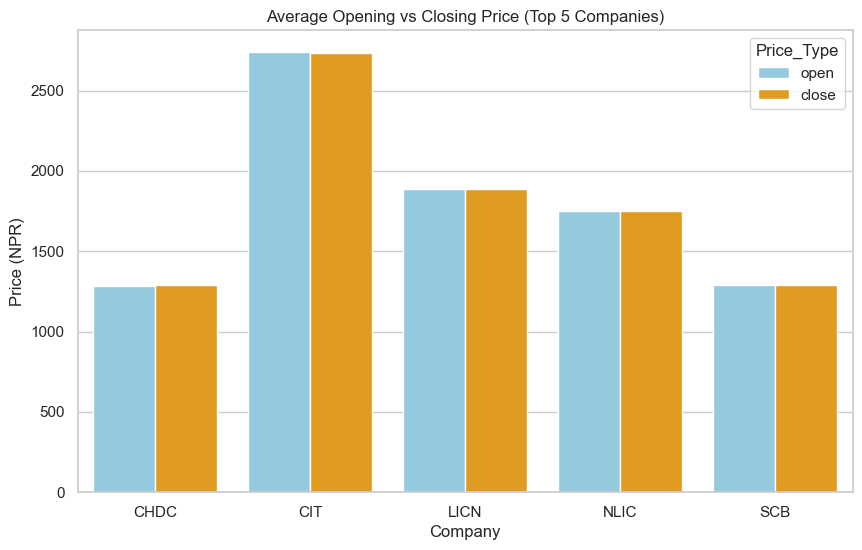

In [68]:
top5 = combined_df.groupby('Company')['close'].mean().sort_values(ascending=False).head(5).index

top5_df = combined_df[combined_df['Company'].isin(top5)]

avg_prices = top5_df.groupby('Company')[['open','close']].mean().reset_index()

# plot open vs close side by side using melt
plot_df = avg_prices.melt(id_vars='Company', value_vars=['open','close'],
                          var_name='Price_Type', value_name='Price')

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Company', y='Price', hue='Price_Type', data=plot_df, palette=['skyblue','orange'])
plt.ylabel("Price (NPR)")
plt.title("Average Opening vs Closing Price (Top 5 Companies)")
plt.show()



/var/folders/qp/ph7wbvl50mj67bc1v40__gcc0000gn/T/ipykernel_40125/3773369656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Company', y='traded_quantity', data=total_qty, palette="magma")


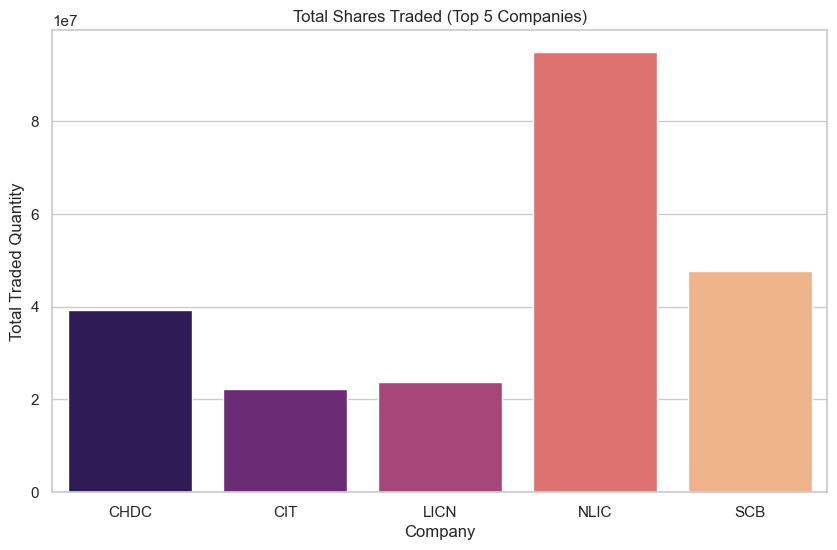

In [53]:
total_qty = combined_df[combined_df['Company'].isin(top5)].groupby('Company')['traded_quantity'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='Company', y='traded_quantity', data=total_qty, palette="magma")
plt.ylabel("Total Traded Quantity")
plt.title("Total Shares Traded (Top 5 Companies)")
plt.show()



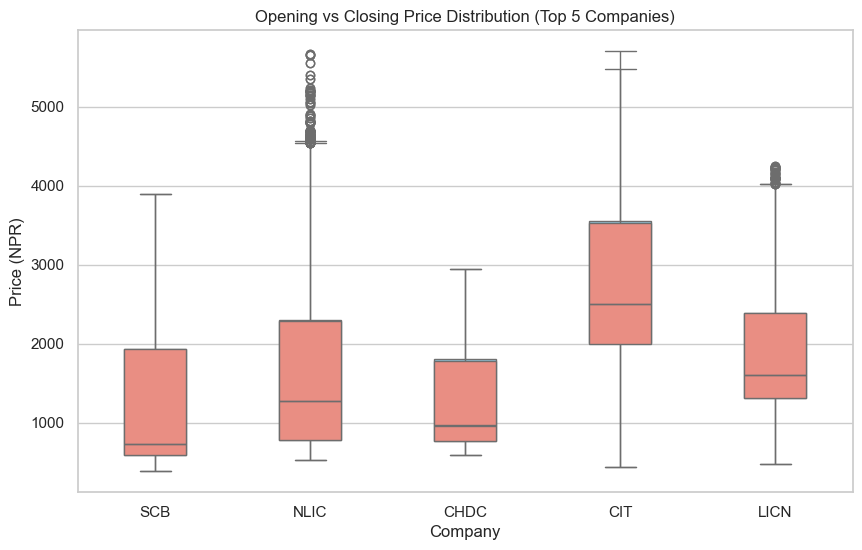

In [55]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Company', y='open', data=combined_df[combined_df['Company'].isin(top5)], color='skyblue', width=0.4)
sns.boxplot(x='Company', y='close', data=combined_df[combined_df['Company'].isin(top5)], color='salmon', width=0.4)
plt.ylabel("Price (NPR)")
plt.title("Opening vs Closing Price Distribution (Top 5 Companies)")
plt.show()
